# N-shift speed benchmark analysis

Confronto delle metriche per diversi valori di `N` (batch size), usando i file prodotti da `tests/Nshift_speed/run_nshift_speed.py`.

In [1]:
from pathlib import Path
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)

# Final timeline highlight plot mode:
# - "scatter": current scatter timeline only
# - "stacked": stacked bar timeline only
# - "both": scatter + stacked
TIMELINE_HIGHLIGHT_PLOT_MODE = "both"
TIMELINE_HIGHLIGHT_DARK_FACTOR = 0.55


# Skip first K slots for steady-state error metric (excludes startup transient):
SKIP_FIRST_K_SLOTS = 5
STRATEGY_COLORS = {
    "Fast": "#1f77b4",
    "Balanced": "#2ca02c",
    "Accurate": "#ff7f0e",
}


In [2]:
candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
online2_dir = next((p for p in candidates if (p / "tests" / "Nshift_speed").exists()), None)
if online2_dir is None:
    raise FileNotFoundError("Cannot locate online2 root (missing tests/Nshift_speed).")

benchmark_dir = online2_dir / "tests" / "Nshift_speed"
output_dir = benchmark_dir / "output"
config_path = benchmark_dir / "config.json"

if not config_path.exists():
    raise FileNotFoundError(f"Missing benchmark config: {config_path}")

import json
import sys
config_data = json.loads(config_path.read_text(encoding="utf-8"))
scenario_path = benchmark_dir / config_data["scenario_path"]
if not scenario_path.exists():
    raise FileNotFoundError(f"Missing scenario file: {scenario_path}")
scenario = json.loads(scenario_path.read_text(encoding="utf-8"))

if str(online2_dir) not in sys.path:
    sys.path.insert(0, str(online2_dir))
import importlib
import config as online2_config
importlib.reload(online2_config)
if not getattr(online2_config, "PREHISTORY_USE_VIRTUAL_PAST", True):
    scenario = dict(scenario)
    scenario["prehistory_slots"] = []
    scenario.setdefault("metadata", {})["prehistory_enabled"] = False
    scenario["metadata"]["prehistory_mock_influence"] = 0.0

summary_path = output_dir / "summary_by_n.csv"
if not summary_path.exists():
    raise FileNotFoundError(f"Missing benchmark summary file: {summary_path}")

print(f"online2_dir:  {online2_dir}")
print(f"benchmark_dir:{benchmark_dir}")
print(f"output_dir:   {output_dir}")
print(f"scenario:     {scenario_path}")

online2_dir:  /home/francis/unipi/carbonshift/carbonshift/online2
benchmark_dir:/home/francis/unipi/carbonshift/carbonshift/online2/tests/Nshift_speed
output_dir:   /home/francis/unipi/carbonshift/carbonshift/online2/tests/Nshift_speed/output
scenario:     /home/francis/unipi/carbonshift/carbonshift/online2/tests/Nshift_speed/scenario_seed_2028.json


In [3]:
summary_df = pd.read_csv(summary_path).sort_values("batch_size").reset_index(drop=True)
summary_df["batch_size"] = summary_df["batch_size"].astype(int)

baseline_summary_path = output_dir / "baseline_summary.csv"
baseline_summary = None
if baseline_summary_path.exists():
    baseline_df = pd.read_csv(baseline_summary_path)
    if not baseline_df.empty:
        baseline_summary = baseline_df.iloc[0].to_dict()

per_request_by_n = {}
per_timeslot_by_n = {}
batch_timings_by_n = {}

for n in summary_df["batch_size"].tolist():
    run_dir = output_dir / f"N{n}"
    per_request_by_n[n] = pd.read_csv(run_dir / "per_request.csv")
    per_timeslot_by_n[n] = pd.read_csv(run_dir / "per_timeslot.csv")
    batch_timings_by_n[n] = pd.read_csv(run_dir / "batch_timings.csv")

threshold = float(scenario["metadata"]["max_error_threshold"])
total_slots = int(scenario["metadata"]["total_slots"])
slot_duration = float(scenario["metadata"]["slot_duration_seconds"])
window_past_decay_slots = int(
    scenario.get("metadata", {}).get(
        "error_window_past_decay_slots",
        getattr(online2_config, "ERROR_WINDOW_PAST_DECAY_SLOTS", 0),
    )
)

summary_df

,execution_mode,batch_size,realtime_slots,realtime_speed_scale,baseline_strategy_name,baseline_strategy_duration,baseline_strategy_error,requests_total,requests_scheduled,requests_unscheduled,batches_executed,total_carbon_cost,global_average_error,global_average_error_real,global_average_error_modeled,global_average_error_real_skip_first_k,global_average_error_modeled_skip_first_k,requests_assigned_with_greedy_fallback,requests_assigned_with_relaxed_retry,solver_time_ms_min,solver_time_ms_max,solver_time_ms_avg,queue_wait_seconds_min,queue_wait_seconds_max,queue_wait_seconds_avg,final_wait_seconds_min,final_wait_seconds_max,final_wait_seconds_avg,baseline_total_carbon_cost,carbon_cost_saving_vs_baseline,carbon_cost_saving_vs_baseline_pct
0,nshift_dp,1,False,1.0,NaN,0,0.0,3102,3102,0,3102,2.699163e+07,3.999033,3.999033,3.999033,0.0,0.0,0,0,0.350652,61.850979,8.305750,0.0,0.0,0.000000,0.000355,80.012770,24.108886,9.282700e+07,6.583537e+07,70.922655
1,nshift_dp,4,False,1.0,NaN,0,0.0,3102,3102,0,776,2.506170e+07,4.028852,4.028852,4.028852,0.0,0.0,0,0,2.172710,1013.164305,90.971529,0.0,20.0,0.257898,0.002173,80.495714,24.014293,9.282700e+07,6.776530e+07,73.001716
2,nshift_dp,6,False,1.0,NaN,0,0.0,3102,3102,0,517,2.456540e+07,4.022405,4.022405,4.022405,0.0,0.0,138,0,15.792423,296.825545,133.520471,0.0,20.0,0.444874,0.015792,80.296826,24.082586,9.282700e+07,6.826159e+07,73.536359
3,nshift_dp,8,False,1.0,NaN,0,0.0,3102,3102,0,388,2.484534e+07,4.014346,4.014346,4.014346,0.0,0.0,288,0,19.245801,477.271393,234.960414,0.0,20.0,0.528691,0.019246,80.393258,24.699959,9.282700e+07,6.798166e+07,73.234791
4,nshift_dp,10,False,1.0,NaN,0,0.0,3102,3102,0,311,2.688486e+07,4.001451,4.001451,4.001451,0.0,0.0,430,0,18.095957,649.325173,309.399518,0.0,20.0,0.760799,0.018096,80.649325,24.749222,9.282700e+07,6.594214e+07,71.037674


## 1) Configurazione del test

In [4]:
pd.DataFrame(
    {
        "parameter": [
            "seed",
            "total_slots",
            "slot_duration_seconds",
            "requests_per_slot",
            "request_rate_std_factor",
            "deadline_min_slack",
            "deadline_max_slack",
            "error_window_past",
            "error_window_future",
            "max_error_threshold",
            "batch_sizes",
        ],
        "value": [
            scenario["metadata"]["seed"],
            scenario["metadata"]["total_slots"],
            scenario["metadata"]["slot_duration_seconds"],
            scenario["metadata"]["requests_per_slot"],
            scenario["metadata"]["request_rate_std_factor"],
            scenario["metadata"]["deadline_min_slack"],
            scenario["metadata"]["deadline_max_slack"],
            scenario["metadata"]["error_window_past"],
            scenario["metadata"]["error_window_future"],
            scenario["metadata"]["max_error_threshold"],
            config_data["batch_sizes"],
        ],
    }
)

,parameter,value
0,seed,2028
1,total_slots,48
2,slot_duration_seconds,10.0
3,requests_per_slot,60.0
4,request_rate_std_factor,0.5
5,deadline_min_slack,0
6,deadline_max_slack,8
7,error_window_past,24
8,error_window_future,8
9,max_error_threshold,4.0


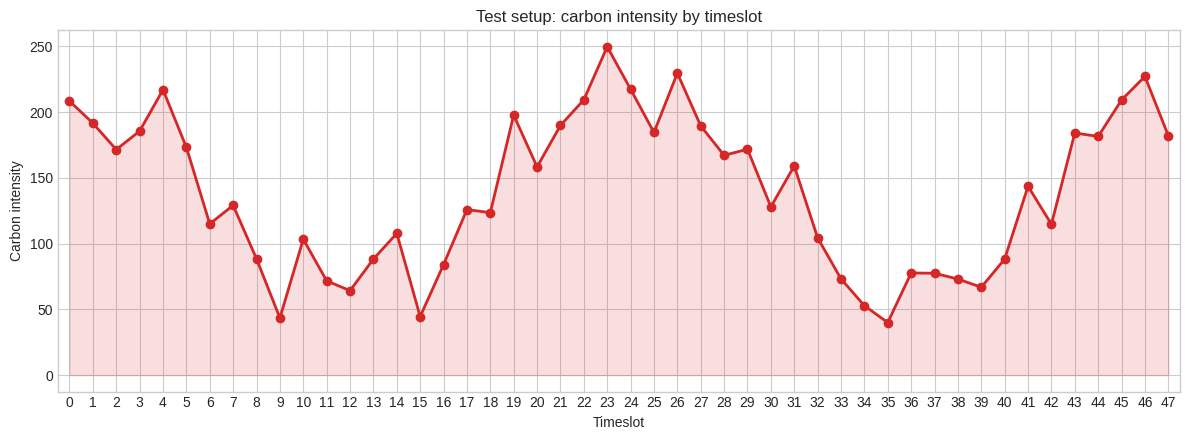

In [5]:
fig, ax = plt.subplots(figsize=(12, 4.5))
slots = list(range(total_slots))
carbon = scenario["carbon_forecast"]
ax.plot(slots, carbon, marker="o", linewidth=2.0, color="tab:red")
ax.fill_between(slots, carbon, alpha=0.15, color="tab:red")
ax.set_xlabel("Timeslot")
ax.set_ylabel("Carbon intensity")
ax.set_title("Test setup: carbon intensity by timeslot")
ax.set_xticks(slots)
ax.set_xlim(-0.5, total_slots - 0.5)
plt.tight_layout()

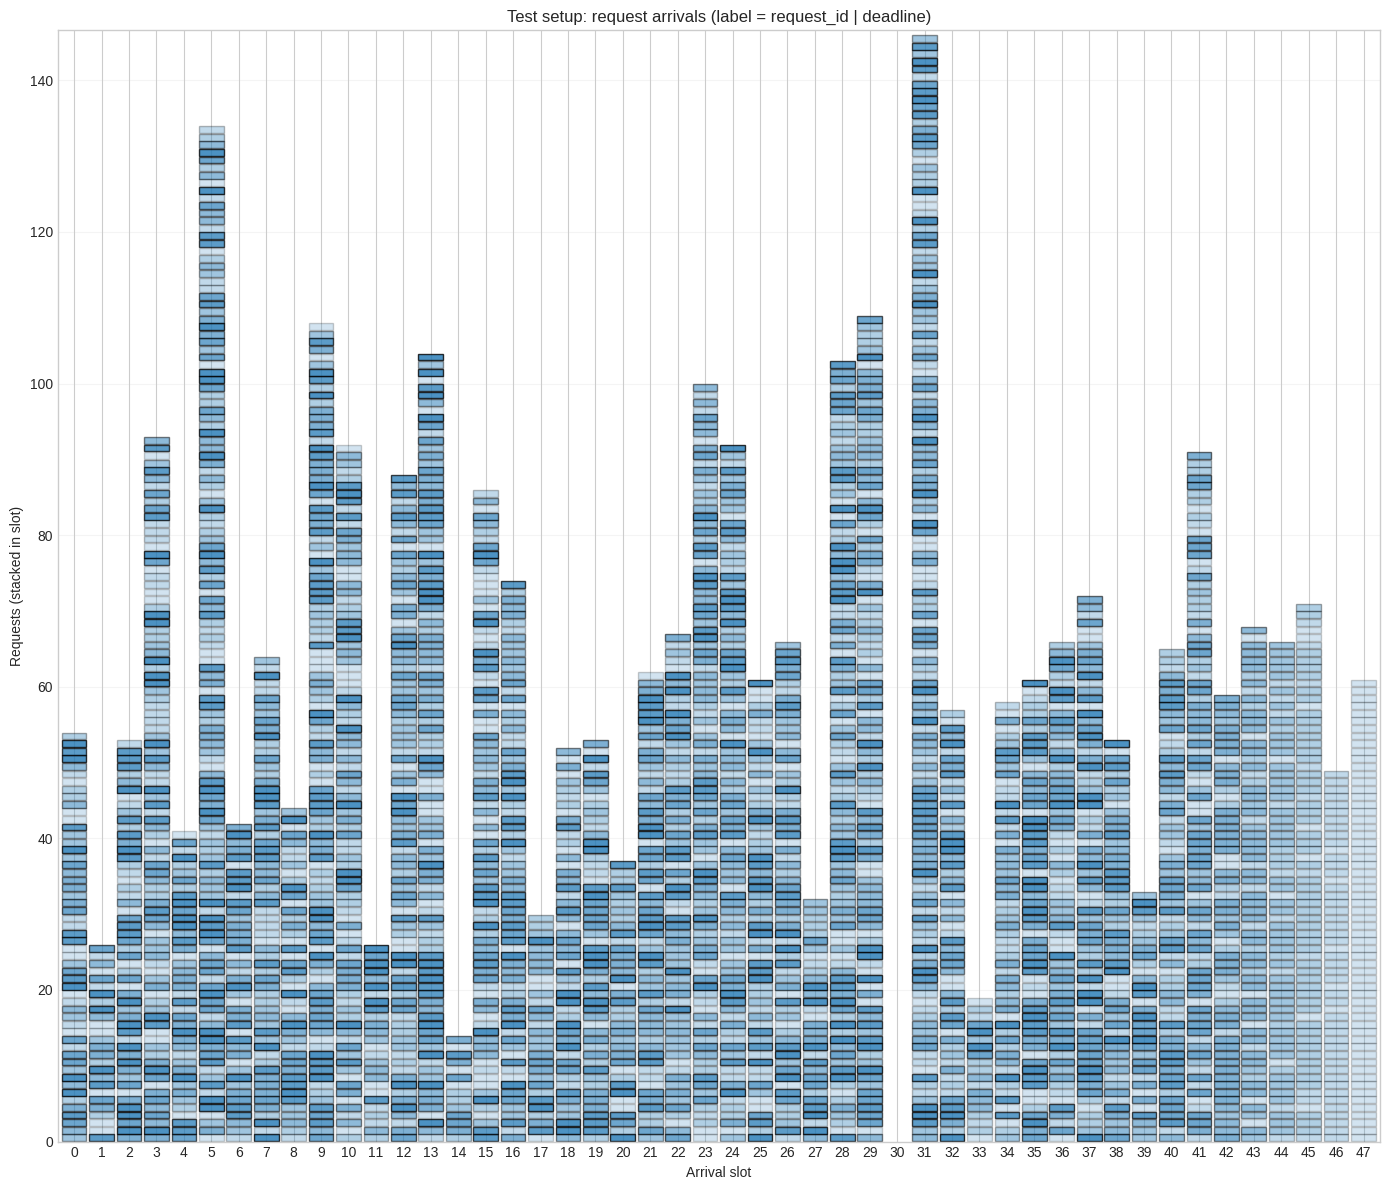

In [6]:
req_df = pd.DataFrame(scenario["requests"]).sort_values(["arrival_slot", "request_id"]).reset_index(drop=True)
grouped = defaultdict(list)
for row in req_df.to_dict(orient="records"):
    grouped[int(row["arrival_slot"])].append(row)

max_stack = max(len(v) for v in grouped.values()) if grouped else 1
fig_h = max(6, min(12, 1.1 + 0.45 * max_stack))
fig, ax = plt.subplots(figsize=(14, fig_h))

show_labels = max_stack < 60  # Avoid cluttering when there are many requests in a slot

for slot in range(total_slots):
    arrivals = grouped.get(slot, [])
    for idx, req in enumerate(arrivals):
        y = idx
        slack = int(req["deadline_slot"]) - int(req["arrival_slot"])
        alpha = 0.2 + 0.6 * (slack / max(1, scenario["metadata"]["deadline_max_slack"]))
        rect = Rectangle((slot - 0.45, y + 0.05), 0.9, 0.9, facecolor="tab:blue", edgecolor="black", alpha=alpha)
        ax.add_patch(rect)
        
        if show_labels:
            ax.text(slot + 0.1, y + 0.5,f"{int(req['request_id'])}|",ha="right", va="center",fontsize=10,fontweight="bold")
            ax.text(slot + 0.15, y + 0.5,f"{int(req['deadline_slot'])}",ha="left", va="center",fontsize=10,style="italic")


ax.set_xlim(-0.6, total_slots - 0.4)
ax.set_ylim(0, max_stack + 0.6)
ax.set_xticks(list(range(total_slots)))
ax.set_xlabel("Arrival slot")
ax.set_ylabel("Requests (stacked in slot)")
ax.set_title("Test setup: request arrivals (label = request_id | deadline)")
ax.grid(True, axis="y", alpha=0.2)
plt.tight_layout()

## 2) Confronto metriche aggregate per N

In [7]:
display_cols = [
    "batch_size",
    "requests_total",
    "batches_executed",
    "solver_time_ms_avg",
    "queue_wait_seconds_avg",
    "final_wait_seconds_avg",
    "total_carbon_cost",
    "baseline_total_carbon_cost",
    "carbon_cost_saving_vs_baseline",
    "carbon_cost_saving_vs_baseline_pct",
    "global_average_error",
    "global_average_error_real",
    "global_average_error_modeled",
    "requests_assigned_with_greedy_fallback",
    "requests_assigned_with_relaxed_retry",
]
available_cols = [c for c in display_cols if c in summary_df.columns]
summary_df[available_cols].round(4)


,batch_size,requests_total,batches_executed,solver_time_ms_avg,queue_wait_seconds_avg,final_wait_seconds_avg,total_carbon_cost,baseline_total_carbon_cost,carbon_cost_saving_vs_baseline,carbon_cost_saving_vs_baseline_pct,global_average_error,global_average_error_real,global_average_error_modeled,requests_assigned_with_greedy_fallback,requests_assigned_with_relaxed_retry
0,1,3102,3102,8.3057,0.0000,24.1089,2.699163e+07,9.282700e+07,6.583537e+07,70.9227,3.9990,3.9990,3.9990,0,0
1,4,3102,776,90.9715,0.2579,24.0143,2.506170e+07,9.282700e+07,6.776530e+07,73.0017,4.0289,4.0289,4.0289,0,0
2,6,3102,517,133.5205,0.4449,24.0826,2.456540e+07,9.282700e+07,6.826159e+07,73.5364,4.0224,4.0224,4.0224,138,0
3,8,3102,388,234.9604,0.5287,24.7000,2.484534e+07,9.282700e+07,6.798166e+07,73.2348,4.0143,4.0143,4.0143,288,0
4,10,3102,311,309.3995,0.7608,24.7492,2.688486e+07,9.282700e+07,6.594214e+07,71.0377,4.0015,4.0015,4.0015,430,0


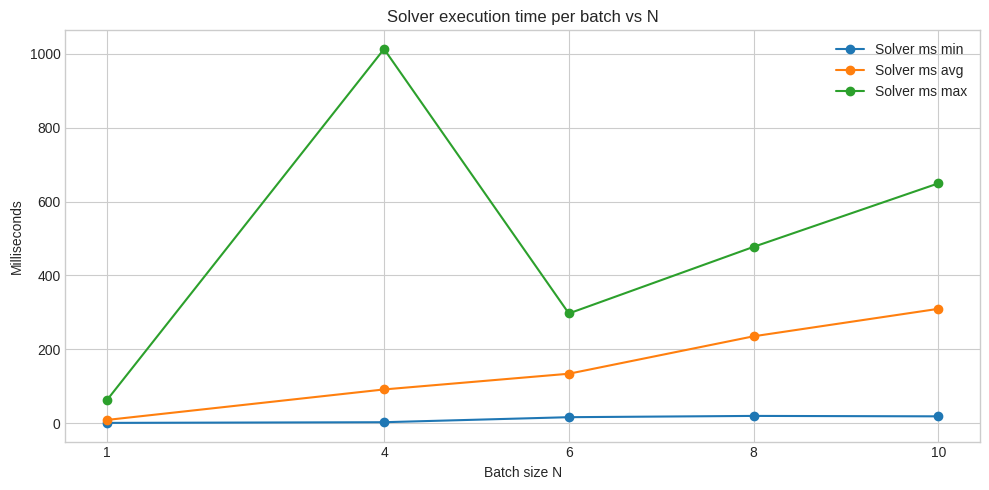

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
x = summary_df["batch_size"].astype(int)
ax.plot(x, summary_df["solver_time_ms_min"], marker="o", label="Solver ms min")
ax.plot(x, summary_df["solver_time_ms_avg"], marker="o", label="Solver ms avg")
ax.plot(x, summary_df["solver_time_ms_max"], marker="o", label="Solver ms max")
ax.set_xlabel("Batch size N")
ax.set_ylabel("Milliseconds")
ax.set_title("Solver execution time per batch vs N")
ax.set_xticks(x.tolist())
ax.legend()
plt.tight_layout()

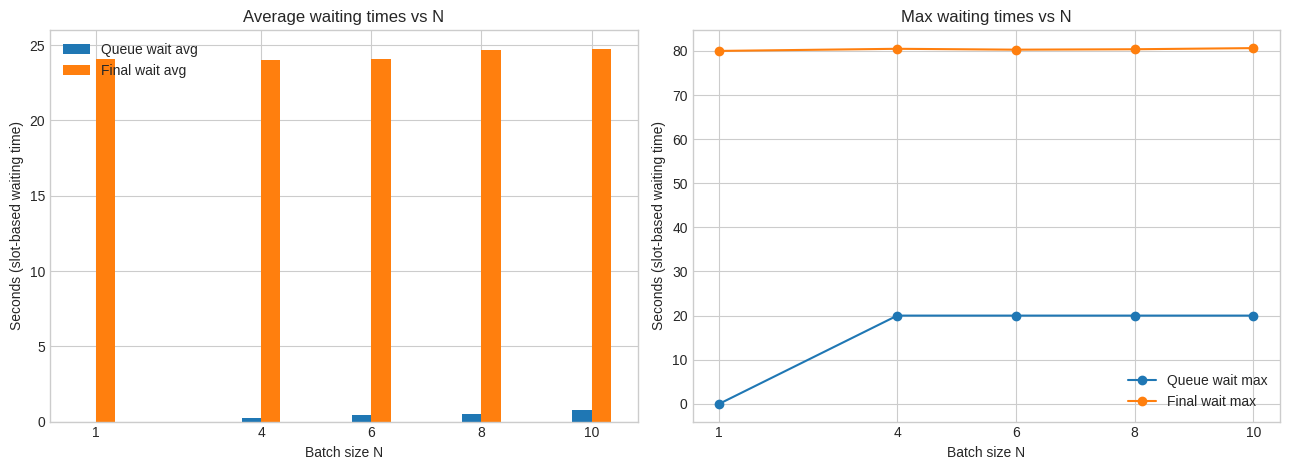

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
x = summary_df["batch_size"].astype(int)

width = 0.35
axes[0].bar(x - width / 2, summary_df["queue_wait_seconds_avg"], width=width, label="Queue wait avg")
axes[0].bar(x + width / 2, summary_df["final_wait_seconds_avg"], width=width, label="Final wait avg")
axes[0].set_xlabel("Batch size N")
axes[0].set_ylabel("Seconds (slot-based waiting time)")
axes[0].set_title("Average waiting times vs N")
axes[0].set_xticks(x.tolist())
axes[0].legend()

axes[1].plot(x, summary_df["queue_wait_seconds_max"], marker="o", label="Queue wait max")
axes[1].plot(x, summary_df["final_wait_seconds_max"], marker="o", label="Final wait max")
axes[1].set_xlabel("Batch size N")
axes[1].set_ylabel("Seconds (slot-based waiting time)")
axes[1].set_title("Max waiting times vs N")
axes[1].set_xticks(x.tolist())
axes[1].legend()

plt.tight_layout()

### Note on global error metrics:

- `global_average_error`: mean(error) over modeled assignments (**includes synthetic prehistory**).
- `global_average_error_real`: mean(error) over only real requests (**excludes synthetic prehistory**).
- `global_average_error_skip_first_k`: mean(error) over real requests with `scheduled_slot >= SKIP_FIRST_K_SLOTS` (startup ignored).
- `Mean of timeslot history (modeled, last run/slot)`: arithmetic mean of the cell-15 modeled series over timeslots.


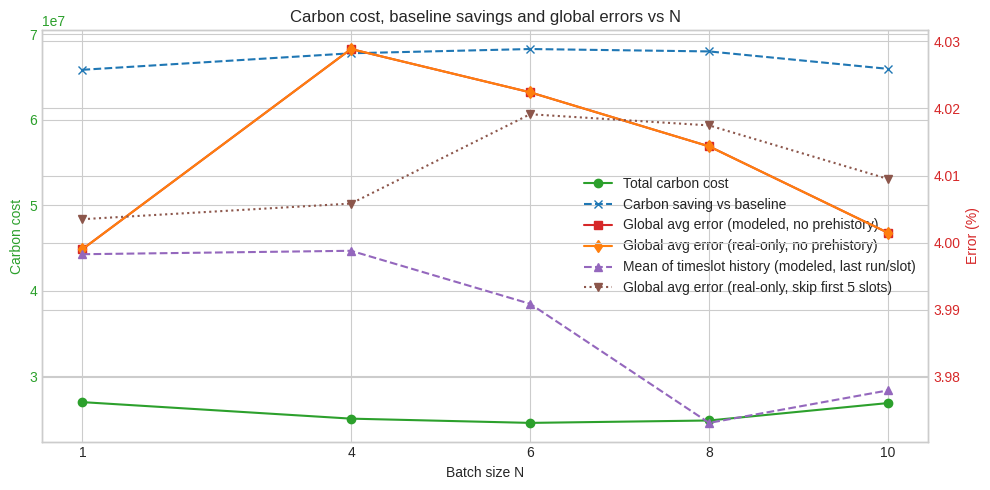

In [10]:
# global_average_error is modeled (includes synthetic prehistory).
# global_average_error_real excludes synthetic prehistory.
# We also compute the mean value of the modeled timeslot history used in cell 15
# (last solver execution per slot) to compare aggregate definitions.

def _history_last_run_per_slot(req_df, timings_df, scenario_payload, total_slots_value):
    seq_col = "batch_sequence" if "batch_sequence" in req_df.columns else "included_in_batch_sequence"
    slot_col = "current_slot" if "current_slot" in timings_df.columns else "slot"

    req_df["scheduled_slot"] = pd.to_numeric(req_df["scheduled_slot"], errors="coerce")
    req_df["error"] = pd.to_numeric(req_df["error"], errors="coerce")
    req_df[seq_col] = pd.to_numeric(req_df[seq_col], errors="coerce")
    req_df = req_df.dropna(subset=["scheduled_slot", "error", seq_col])
    req_df = req_df[req_df["scheduled_slot"] >= 0]
    req_df["scheduled_slot"] = req_df["scheduled_slot"].astype(int)
    req_df[seq_col] = req_df[seq_col].astype(int)

    timings_df["batch_sequence"] = pd.to_numeric(timings_df["batch_sequence"], errors="coerce")
    timings_df[slot_col] = pd.to_numeric(timings_df[slot_col], errors="coerce")
    timings_df = timings_df.dropna(subset=["batch_sequence", slot_col])
    timings_df["batch_sequence"] = timings_df["batch_sequence"].astype(int)
    timings_df[slot_col] = timings_df[slot_col].astype(int)

    w_past = int(scenario_payload["metadata"]["error_window_past"])
    w_future = int(scenario_payload["metadata"]["error_window_future"])
    prehistory = scenario_payload.get("prehistory_slots", [])
    prehistory_by_slot = {
        int(p["slot"]): {
            "count": int(p["request_count"]),
            "error": float(p["error_per_request"]),
        }
        for p in prehistory
    }

    rows = []
    for row in timings_df.sort_values("batch_sequence").itertuples(index=False):
        run_seq = int(row.batch_sequence)
        current_slot = int(getattr(row, slot_col))

        state_df = req_df[(req_df[seq_col] <= run_seq) & (req_df["scheduled_slot"] >= 0)]

        window_start_modeled = current_slot - w_past
        window_start_real = max(0, window_start_modeled)
        window_end = min(total_slots_value - 1, current_slot + w_future)

        in_window = state_df[
            (state_df["scheduled_slot"] >= window_start_real)
            & (state_df["scheduled_slot"] <= window_end)
        ]
        real_sum = float(in_window["error"].sum()) if not in_window.empty else 0.0
        real_cnt = int(len(in_window))

        real_weighted_cnt = 0.0
        real_weighted_sum = 0.0
        modeled_weighted_cnt = 0.0
        modeled_weighted_sum = 0.0
        for offset in range(1, window_past_decay_slots + 1):
            decay_slot = window_start_modeled - offset
            decay_weight = float(window_past_decay_slots - offset + 1) / float(window_past_decay_slots + 1)

            slot_real = state_df[state_df["scheduled_slot"] == decay_slot]["error"]
            slot_real_cnt = int(len(slot_real))
            slot_real_sum = float(slot_real.sum()) if slot_real_cnt else 0.0
            if slot_real_cnt > 0:
                weighted_real_cnt = float(slot_real_cnt) * decay_weight
                real_weighted_cnt += weighted_real_cnt
                real_weighted_sum += (slot_real_sum / float(slot_real_cnt)) * weighted_real_cnt

            slot_modeled_cnt = float(slot_real_cnt)
            slot_modeled_sum = slot_real_sum
            pre_info = prehistory_by_slot.get(decay_slot)
            if pre_info is not None:
                slot_modeled_cnt += float(pre_info["count"])
                slot_modeled_sum += float(pre_info["count"]) * float(pre_info["error"])
            if slot_modeled_cnt > 0.0:
                weighted_modeled_cnt = slot_modeled_cnt * decay_weight
                modeled_weighted_cnt += weighted_modeled_cnt
                modeled_weighted_sum += (slot_modeled_sum / slot_modeled_cnt) * weighted_modeled_cnt

        pre_cnt = 0
        pre_sum = 0.0
        for p_slot, p_info in prehistory_by_slot.items():
            if window_start_modeled <= p_slot <= window_end:
                p_count = int(p_info["count"])
                p_err = float(p_info["error"])
                pre_cnt += p_count
                pre_sum += p_count * p_err

        real_cnt_effective = float(real_cnt) + real_weighted_cnt
        real_sum_effective = real_sum + real_weighted_sum
        modeled_cnt = float(real_cnt + pre_cnt) + modeled_weighted_cnt
        rows.append(
            {
                "timeslot": current_slot,
                "run_seq": run_seq,
                "avg_real": (real_sum_effective / real_cnt_effective) if real_cnt_effective > 0.0 else 0.0,
                "avg_modeled": ((real_sum + pre_sum + modeled_weighted_sum) / modeled_cnt) if modeled_cnt > 0.0 else 0.0,
            }
        )

    hist_df = pd.DataFrame(rows)
    if hist_df.empty:
        return hist_df
    return hist_df.sort_values(["timeslot", "run_seq"]).groupby("timeslot", as_index=False).last()


summary_for_plot = summary_df.copy()
history_avg_modeled = []
global_error_skip_first_k = []
global_error_from_requests = []
prehistory_disabled = len(scenario.get("prehistory_slots", [])) == 0
for n in summary_for_plot["batch_size"].tolist():
    hist = _history_last_run_per_slot(
        per_request_by_n[n].copy(),
        batch_timings_by_n[n].copy(),
        scenario,
        total_slots,
    )
    history_avg_modeled.append(float(hist["avg_modeled"].mean()) if not hist.empty else 0.0)

    req_all = per_request_by_n[n].copy()
    req_all["scheduled_slot"] = pd.to_numeric(req_all["scheduled_slot"], errors="coerce")
    req_all["error"] = pd.to_numeric(req_all["error"], errors="coerce")
    req_all = req_all.dropna(subset=["scheduled_slot", "error"])
    global_error_from_requests.append(float(req_all["error"].mean()) if not req_all.empty else 0.0)

    req_local = req_all[req_all["scheduled_slot"] >= SKIP_FIRST_K_SLOTS]
    global_error_skip_first_k.append(float(req_local["error"].mean()) if not req_local.empty else 0.0)

summary_for_plot["history_avg_modeled_last_run"] = history_avg_modeled
summary_for_plot["global_average_error_skip_first_k"] = global_error_skip_first_k
summary_for_plot["global_average_error_from_requests"] = global_error_from_requests

fig, ax1 = plt.subplots(figsize=(10, 5))
x = summary_for_plot["batch_size"].astype(int)

ax1.plot(x, summary_for_plot["total_carbon_cost"], marker="o", color="tab:green", label="Total carbon cost")
# if "baseline_total_carbon_cost" in summary_for_plot.columns and not summary_for_plot.empty:
#     baseline_cost = float(summary_for_plot["baseline_total_carbon_cost"].iloc[0])
#     ax1.axhline(
#         baseline_cost,
#         color="tab:gray",
#         linestyle=":",
#         linewidth=2.0,
#         label="Greedy baseline carbon cost",
#     )
if "carbon_cost_saving_vs_baseline" in summary_for_plot.columns:
    ax1.plot(
        x,
        summary_for_plot["carbon_cost_saving_vs_baseline"],
        marker="x",
        linestyle="--",
        color="tab:blue",
        label="Carbon saving vs baseline",
    )
ax1.set_xlabel("Batch size N")
ax1.set_ylabel("Carbon cost", color="tab:green")
ax1.tick_params(axis="y", labelcolor="tab:green")
ax1.set_xticks(x.tolist())

ax2 = ax1.twinx()
modeled_series = summary_for_plot["global_average_error"]
modeled_label = "Global avg error (modeled, with synthetic)"
real_series = (
    summary_for_plot["global_average_error_real"]
    if "global_average_error_real" in summary_for_plot.columns
    else summary_for_plot["global_average_error"]
)
real_label = "Global avg error (real-only)"
if prehistory_disabled:
    modeled_series = summary_for_plot["global_average_error_from_requests"]
    modeled_label = "Global avg error (modeled, no prehistory)"
    real_series = summary_for_plot["global_average_error_from_requests"]
    real_label = "Global avg error (real-only, no prehistory)"
ax2.plot(
    x,
    modeled_series,
    marker="s",
    color="tab:red",
    label=modeled_label,
)
if "global_average_error_real" in summary_for_plot.columns or prehistory_disabled:
    ax2.plot(
        x,
        real_series,
        marker="d",
        color="tab:orange",
        label=real_label,
    )
ax2.plot(
    x,
    summary_for_plot["history_avg_modeled_last_run"],
    marker="^",
    linestyle="--",
    color="tab:purple",
    label="Mean of timeslot history (modeled, last run/slot)",

)
if SKIP_FIRST_K_SLOTS > 0:
    ax2.plot(
        x,
        summary_for_plot["global_average_error_skip_first_k"],
        marker="v",
        color="tab:brown",
        linestyle=":",
        label=f"Global avg error (real-only, skip first {SKIP_FIRST_K_SLOTS} slots)",
    )
ax2.set_ylabel("Error (%)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")
ax1.set_title("Carbon cost, baseline savings and global errors vs N")
plt.tight_layout()


In [11]:
# Strategy breakdown per batch size
# Shows request counts and error metrics by strategy (respects SKIP_FIRST_K_SLOTS)
SKIP_FIRST_K_SLOTS  = 0
def _strategy_breakdown_table(per_request_map, skip_k_slots=0):
    """
    Returns dict[N -> pd.DataFrame] with columns:
      - strategy_name
      - request_count
      - avg_error
      - total_error
      - weighted_count (for later aggregation)
    """
    result = {}
    for n, df in per_request_map.items():
        local = df.copy()
        local['scheduled_slot'] = pd.to_numeric(local['scheduled_slot'], errors='coerce')
        local['error'] = pd.to_numeric(local['error'], errors='coerce')
        local = local.dropna(subset=['scheduled_slot', 'error'])
        
        if skip_k_slots > 0:
            local = local[local['scheduled_slot'] >= skip_k_slots]
        
        local['strategy_name'] = local.get('strategy_name', 'Unknown').fillna('Unknown').astype(str)
        
        rows = []
        for strategy in sorted(local['strategy_name'].unique()):
            strategy_df = local[local['strategy_name'] == strategy]
            cnt = len(strategy_df)
            avg_err = float(strategy_df['error'].mean()) if cnt > 0 else 0.0
            total_err = float(strategy_df['error'].sum()) if cnt > 0 else 0.0
            
            rows.append({
                'strategy_name': strategy,
                'request_count': cnt,
                'avg_error': avg_err,
                'total_error': total_err,
            })
        
        result[n] = pd.DataFrame(rows) if rows else pd.DataFrame()
    return result

strategy_breakdowns = _strategy_breakdown_table(per_request_by_n, skip_k_slots=SKIP_FIRST_K_SLOTS)

for n in sorted(strategy_breakdowns.keys()):
    df_strat = strategy_breakdowns[n]
    if df_strat.empty:
        print(f'N={int(n)}: (no requests)')
        continue
    
    total_cnt = df_strat['request_count'].sum()
    total_err = df_strat['total_error'].sum()
    weighted_avg_error = total_err / total_cnt if total_cnt > 0 else 0.0
    
    print(f'\nN={int(n)} (skip_first_k={SKIP_FIRST_K_SLOTS}):  total={int(total_cnt)}, weighted_avg_error={weighted_avg_error:.4f}')
    print(df_strat[['strategy_name', 'request_count', 'avg_error']].to_string(index=False))



N=1 (skip_first_k=0):  total=3102, weighted_avg_error=3.9990
strategy_name  request_count  avg_error
     Balanced           1242        2.5
         Fast           1860        5.0

N=4 (skip_first_k=0):  total=3102, weighted_avg_error=4.0289
strategy_name  request_count  avg_error
     Accurate             74        0.0
     Balanced           1057        2.5
         Fast           1971        5.0

N=6 (skip_first_k=0):  total=3102, weighted_avg_error=4.0224
strategy_name  request_count  avg_error
     Accurate            217        0.0
     Balanced            779        2.5
         Fast           2106        5.0

N=8 (skip_first_k=0):  total=3102, weighted_avg_error=4.0143
strategy_name  request_count  avg_error
     Accurate            339        0.0
     Balanced            545        2.5
         Fast           2218        5.0

N=10 (skip_first_k=0):  total=3102, weighted_avg_error=4.0015
strategy_name  request_count  avg_error
     Accurate            475        0.0
     Bala

## 3) Errori su window e distribuzioni dettagliate

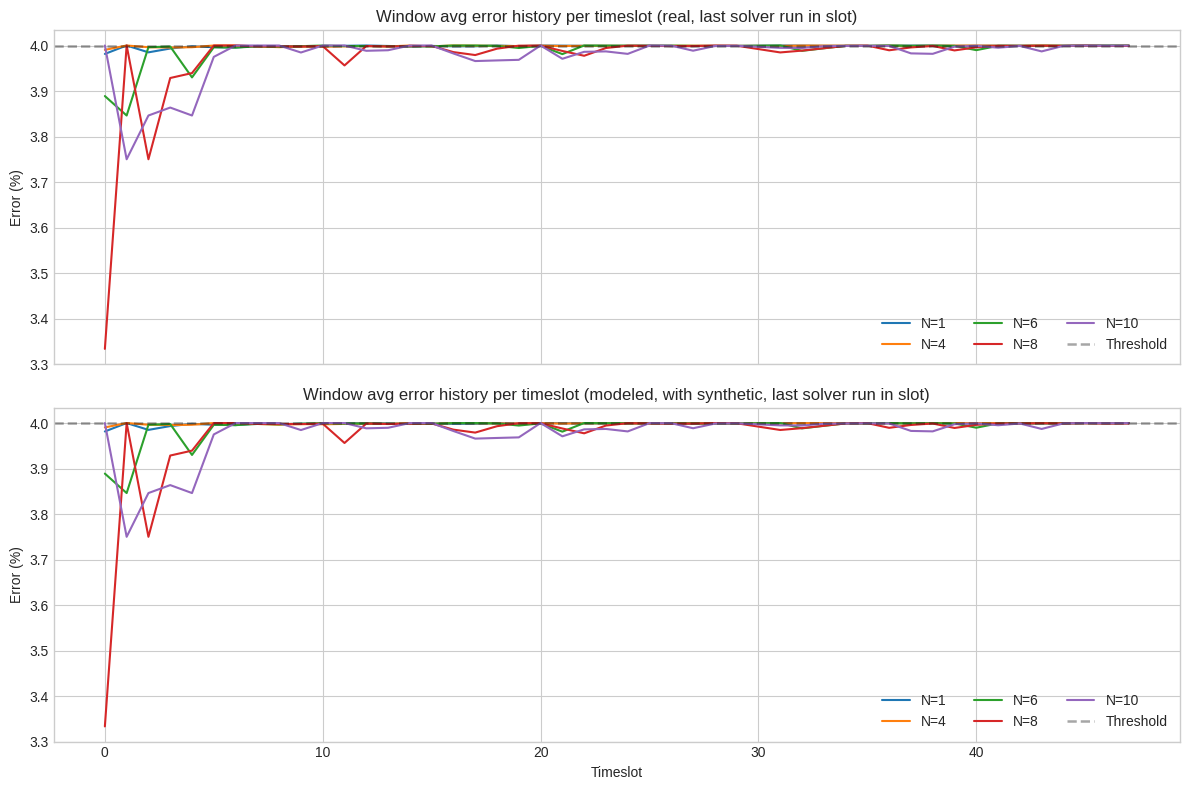

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for n in summary_df["batch_size"].tolist():
    # Reuse the same run-history reconstruction used by the global-error chart.
    # Each point is the LAST solver execution observed for that timeslot.
    hist = _history_last_run_per_slot(
        per_request_by_n[n].copy(),
        batch_timings_by_n[n].copy(),
        scenario,
        total_slots,
    )

    if hist.empty:
        continue
    axes[0].plot(hist["timeslot"], hist["avg_real"], label=f"N={n}")
    axes[1].plot(hist["timeslot"], hist["avg_modeled"], label=f"N={n}")

axes[0].axhline(threshold, linestyle="--", linewidth=1.8, color="black", alpha=0.35, label="Threshold")
axes[1].axhline(threshold, linestyle="--", linewidth=1.8, color="black", alpha=0.35, label="Threshold")

axes[0].set_ylabel("Error (%)")
axes[0].set_title("Window avg error history per timeslot (real, last solver run in slot)")
axes[0].legend(ncol=3)

axes[1].set_xlabel("Timeslot")
axes[1].set_ylabel("Error (%)")
axes[1].set_title("Window avg error history per timeslot (modeled, with synthetic, last solver run in slot)")
axes[1].legend(ncol=3)

plt.tight_layout()


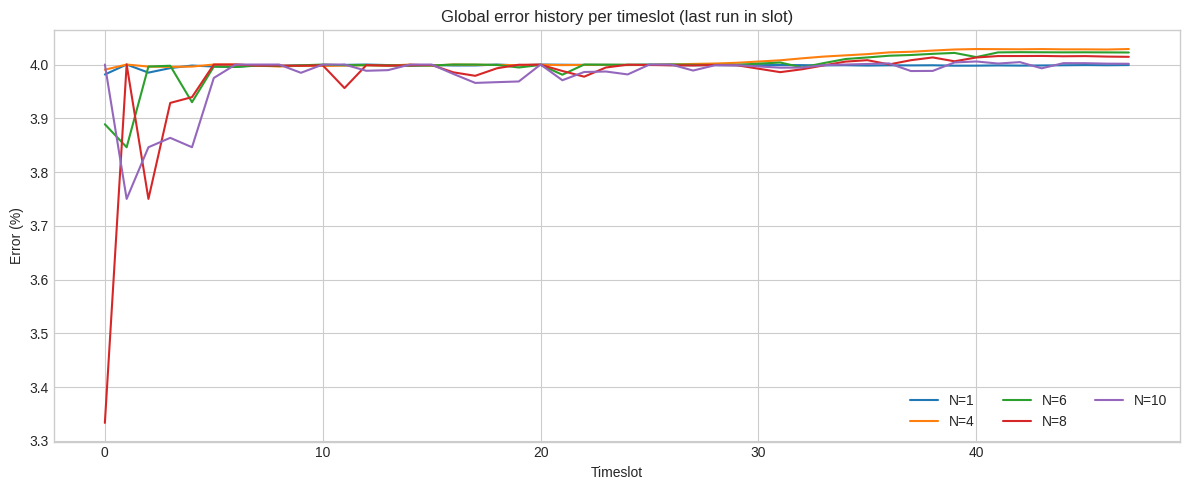

In [13]:
SELECTED_N = None
# Window avg error history (real) with global error overlay
# Global error history per timeslot (last solver run in slot)
def _global_error_history_last_run(per_request_df, timings_df):
    seq_col = "batch_sequence" if "batch_sequence" in per_request_df.columns else "included_in_batch_sequence"
    slot_col = "current_slot" if "current_slot" in timings_df.columns else "slot"

    req = per_request_df.copy()
    req["scheduled_slot"] = pd.to_numeric(req["scheduled_slot"], errors="coerce")
    req["error"] = pd.to_numeric(req["error"], errors="coerce")
    req[seq_col] = pd.to_numeric(req[seq_col], errors="coerce")
    req = req.dropna(subset=["scheduled_slot", "error", seq_col])
    req = req[req["scheduled_slot"] >= 0]

    timings = timings_df.copy()
    timings["batch_sequence"] = pd.to_numeric(timings["batch_sequence"], errors="coerce")
    timings[slot_col] = pd.to_numeric(timings[slot_col], errors="coerce")
    timings = timings.dropna(subset=["batch_sequence", slot_col])

    last_runs = timings.groupby(slot_col)["batch_sequence"].max().to_dict()
    rows = []
    for slot, run_seq in sorted(last_runs.items()):
        state = req[req[seq_col] <= run_seq]
        avg = float(state["error"].mean()) if not state.empty else 0.0
        rows.append({"timeslot": int(slot), "run_seq": int(run_seq), "global_error": avg})
    return pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(12, 5))
selected_ns = summary_df["batch_size"].tolist()
if SELECTED_N is not None:
    if int(SELECTED_N) not in [int(v) for v in selected_ns]:
        raise ValueError(f"SELECTED_N={SELECTED_N} not found in summary_by_n.csv")
    selected_ns = [int(SELECTED_N)]

for n in selected_ns:
    hist = _global_error_history_last_run(
        per_request_by_n[n].copy(),
        batch_timings_by_n[n].copy(),
    )
    if hist.empty:
        continue
    ax.plot(hist["timeslot"], hist["global_error"], label=f"N={int(n)}")

ax.set_xlabel("Timeslot")
ax.set_ylabel("Error (%)")
ax.set_title("Global error history per timeslot (last run in slot)")
ax.legend(ncol=3)
plt.tight_layout()


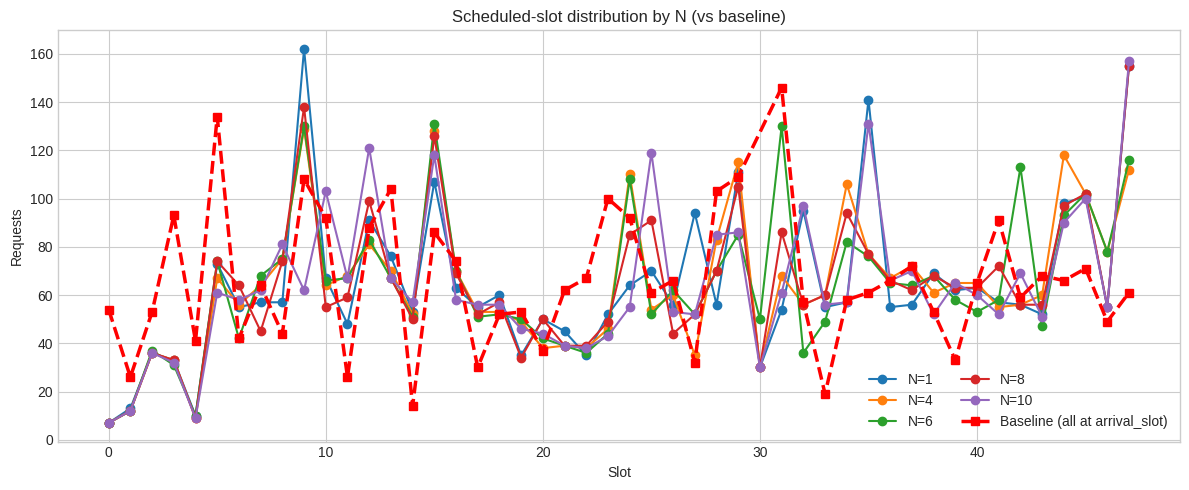

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))

for n, df in per_request_by_n.items():
    local = df.copy()
    local["scheduled_slot"] = pd.to_numeric(local["scheduled_slot"], errors="coerce")
    counts = local.dropna(subset=["scheduled_slot"]).groupby("scheduled_slot").size().sort_index()
    ax.plot(counts.index.astype(int), counts.values, marker="o", label=f"N={n}")

baseline_df = pd.read_csv(output_dir / "baseline_greedy" / "per_request.csv")
baseline_counts = baseline_df.groupby("arrival_slot").size().sort_index()
ax.plot(
    baseline_counts.index.astype(int),
    baseline_counts.values,
    marker="s",
    linestyle="--",
    color="red",
    linewidth=2.5,
    label="Baseline (all at arrival_slot)",
)

ax.set_xlabel("Slot")
ax.set_ylabel("Requests")
ax.set_title("Scheduled-slot distribution by N (vs baseline)")
ax.legend(ncol=2)
plt.tight_layout()

/tmp/ipykernel_80400/2681538569.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=False)


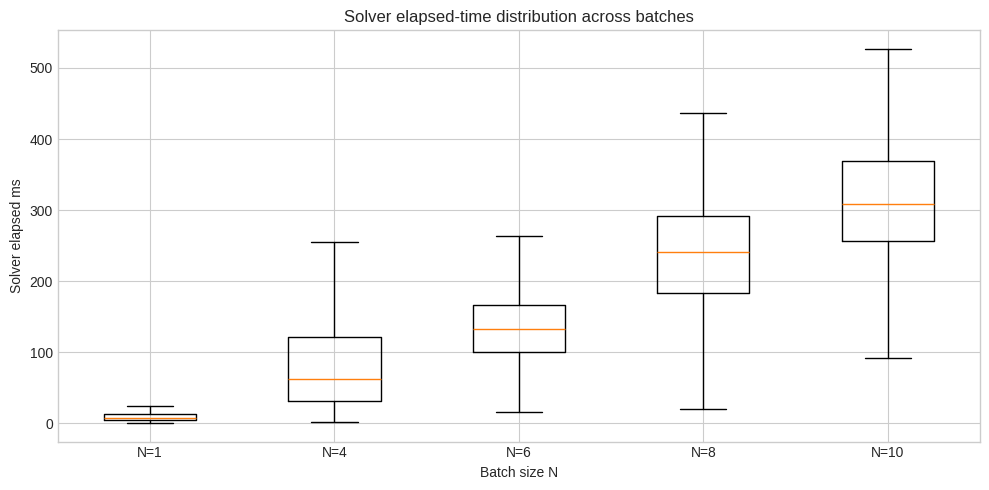

In [15]:
labels = []
data = []
for n, df in batch_timings_by_n.items():
    local = df.copy()
    local = local[local["scheduled"].astype(str).str.lower() == "true"]
    values = pd.to_numeric(local["solver_elapsed_ms"], errors="coerce").dropna().tolist()
    if values:
        labels.append(f"N={int(n)}")
        data.append(values)

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(data, labels=labels, showfliers=False)
ax.set_xlabel("Batch size N")
ax.set_ylabel("Solver elapsed ms")
ax.set_title("Solver elapsed-time distribution across batches")
plt.tight_layout()

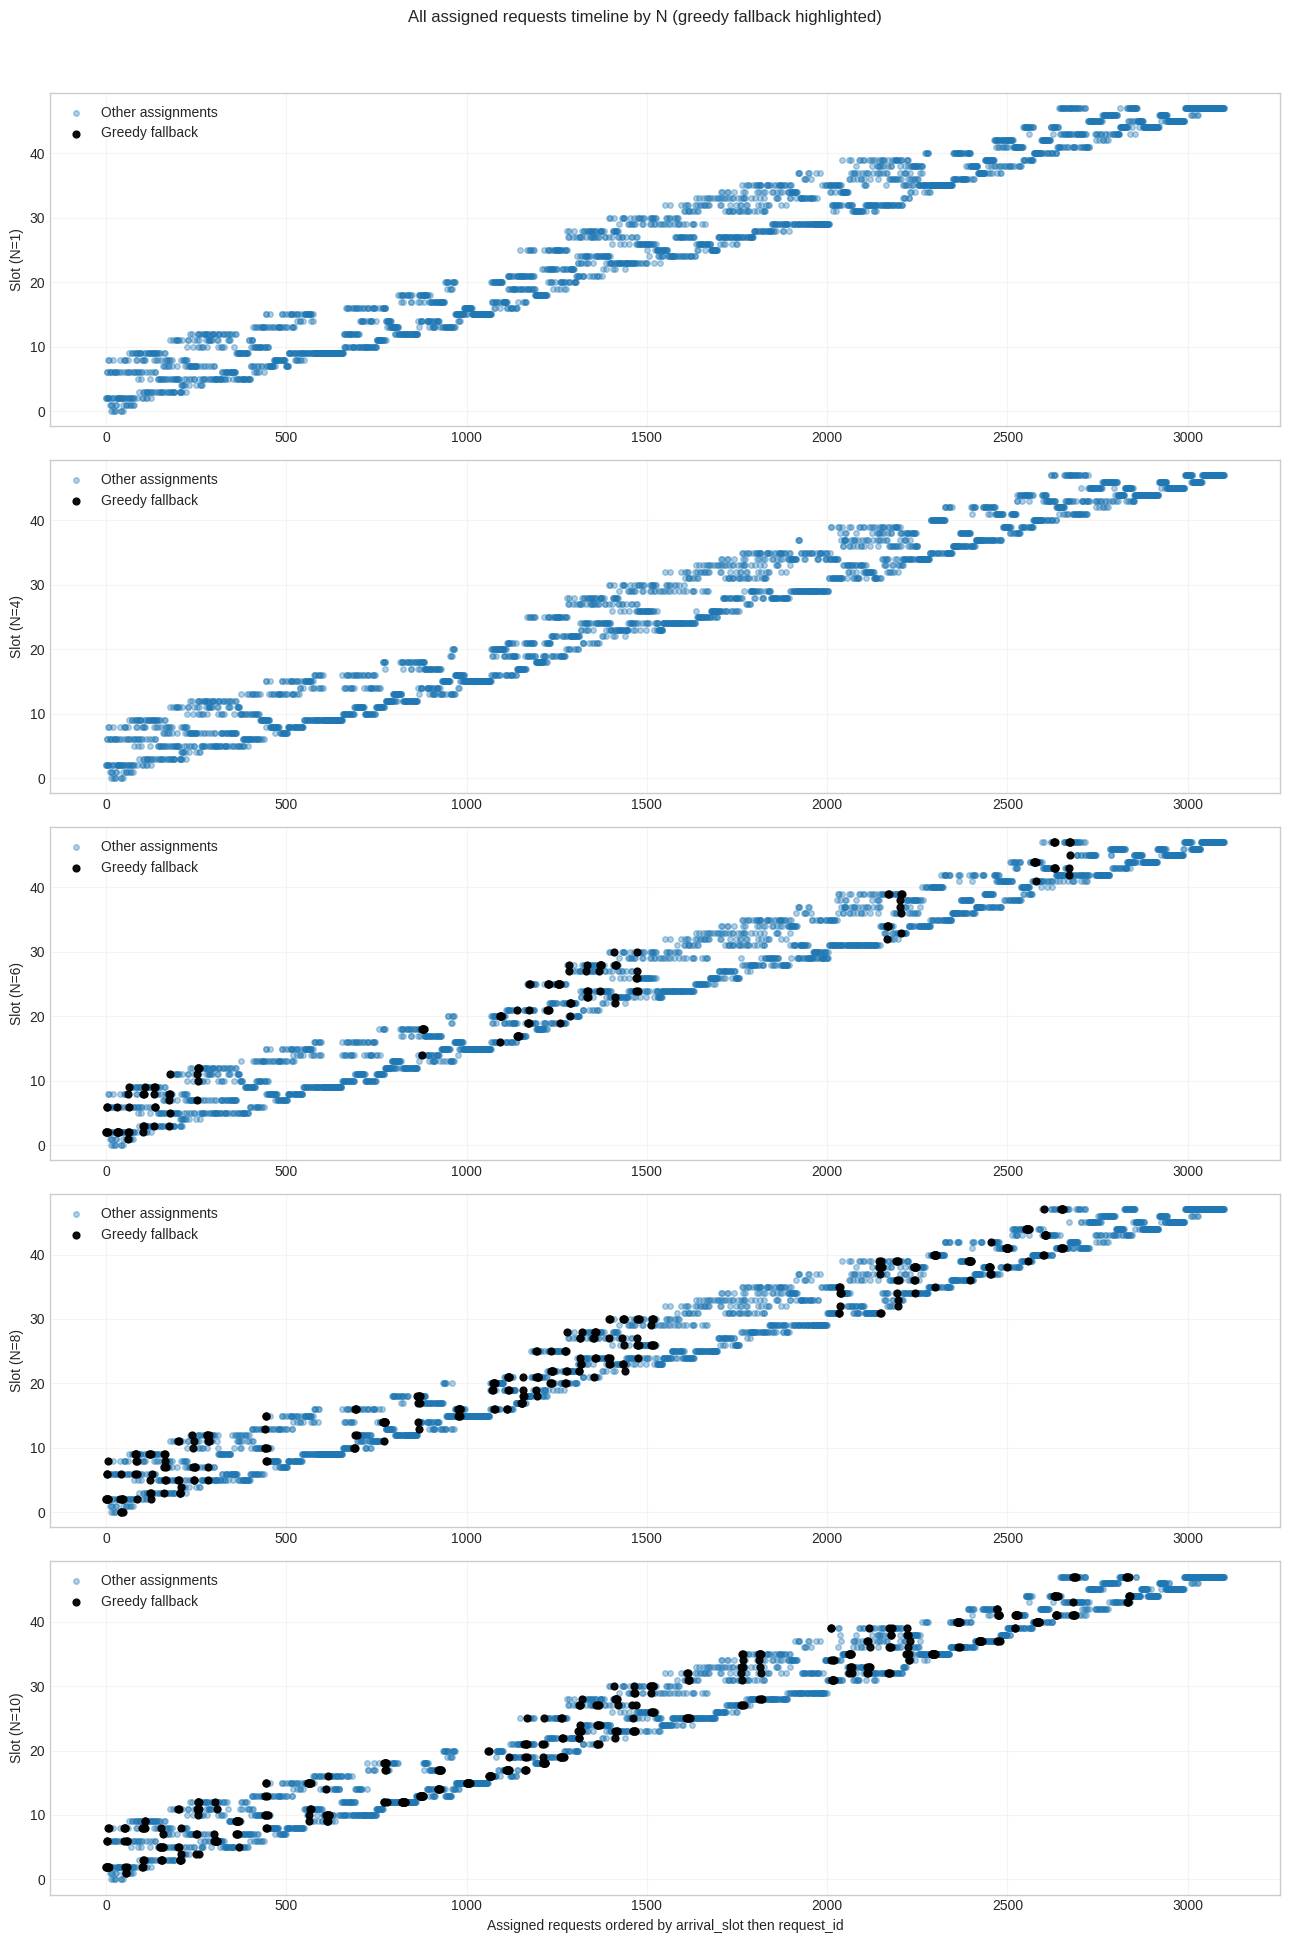

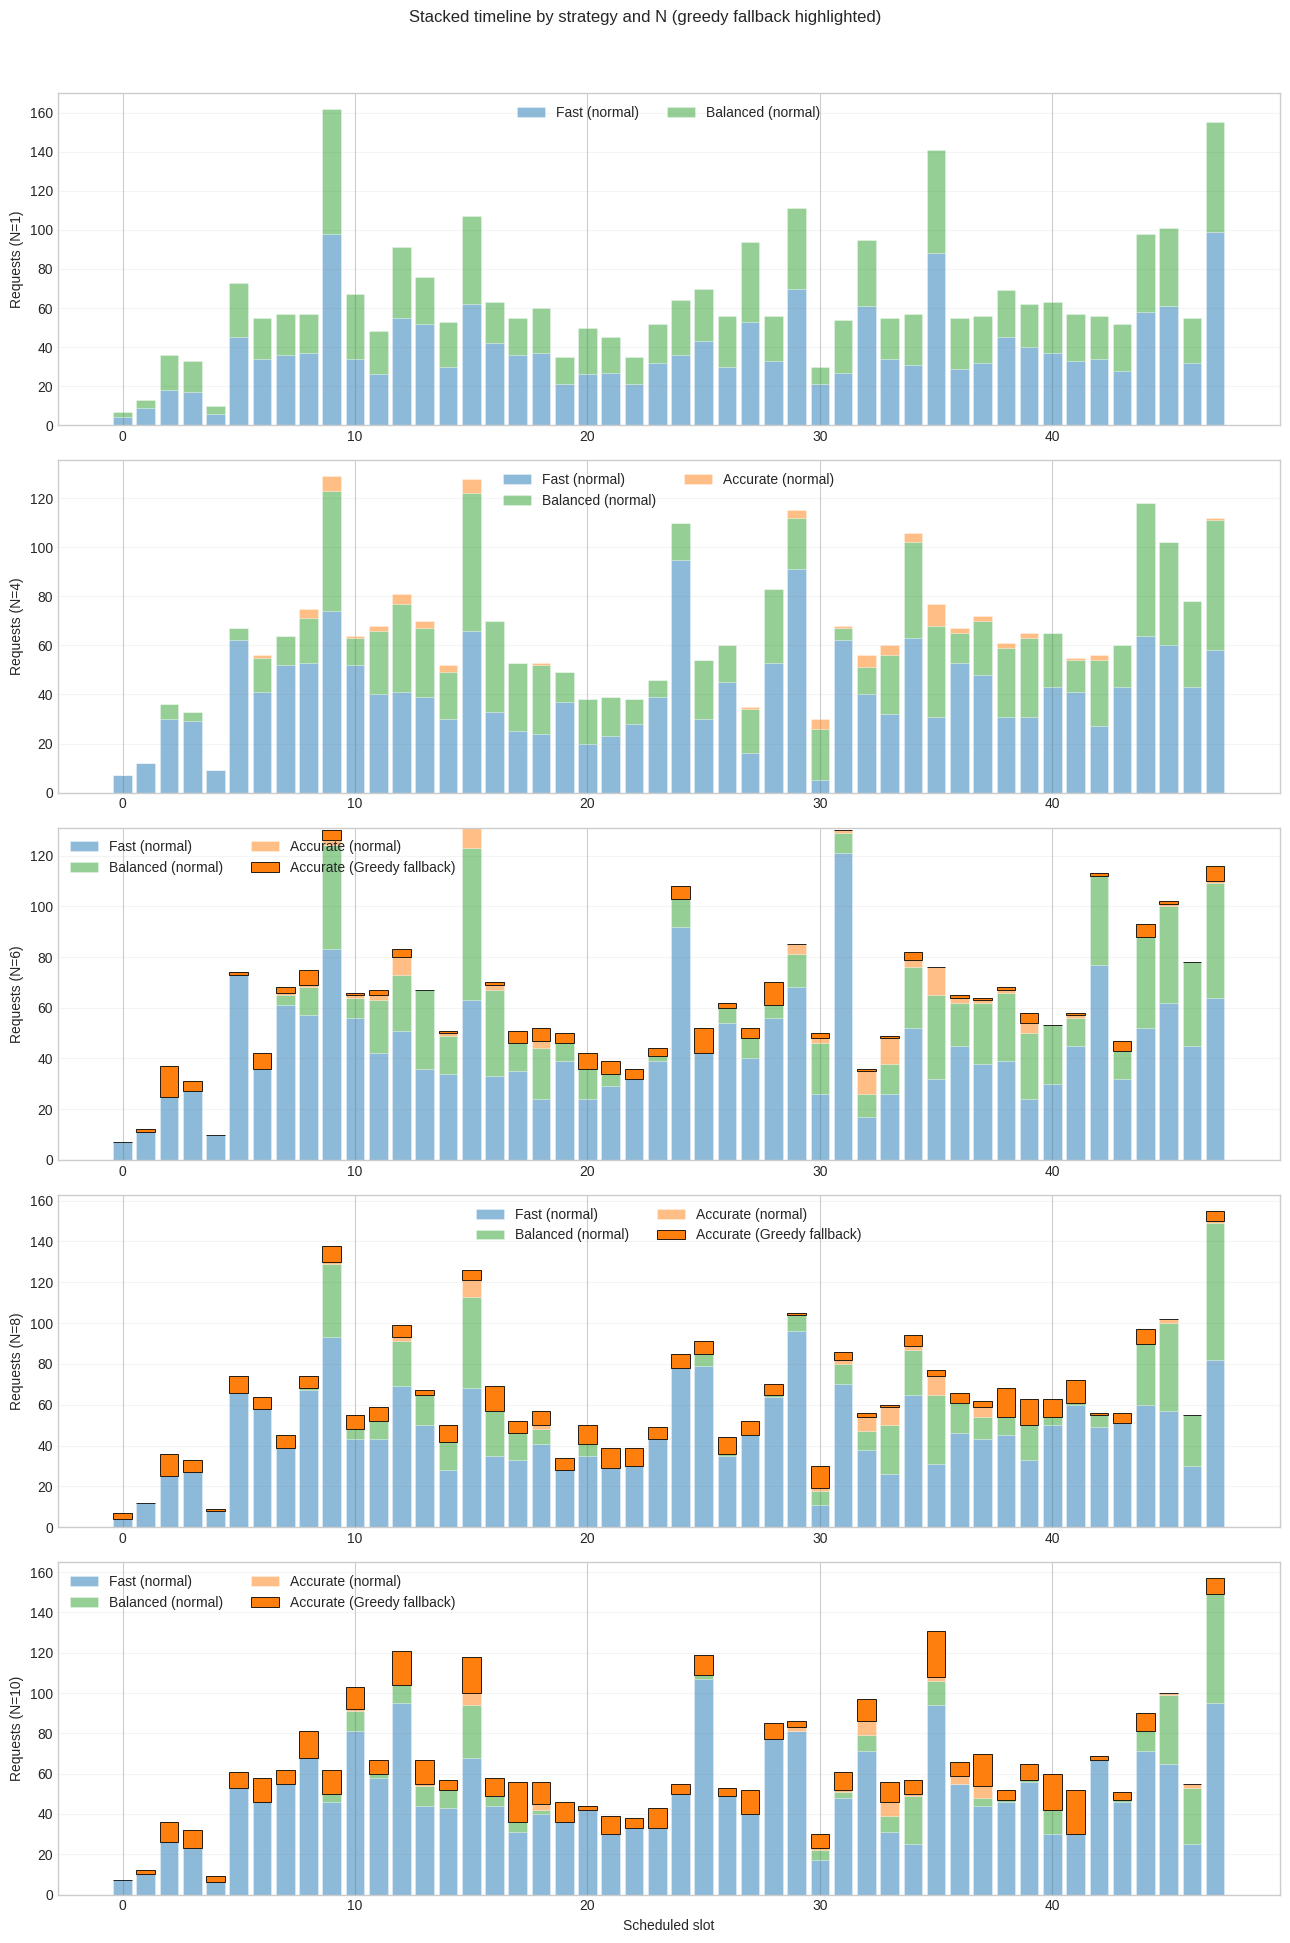

In [16]:
# End-to-end assigned-request timelines across all N.
def _bool_series(values):
    return values.astype(str).str.strip().str.lower().isin(["1", "true", "yes", "y", "t"])


def _resolve_plot_mode(mode):
    normalized = str(mode).strip().lower()
    if normalized not in {"scatter", "stacked", "both"}:
        raise ValueError("TIMELINE_HIGHLIGHT_PLOT_MODE must be one of: scatter, stacked, both")
    return normalized


def _prepare_local(df):
    local = df.copy()
    local["request_id"] = pd.to_numeric(local["request_id"], errors="coerce")
    local["arrival_slot"] = pd.to_numeric(local["arrival_slot"], errors="coerce")
    local["scheduled_slot"] = pd.to_numeric(local["scheduled_slot"], errors="coerce")
    local = local.dropna(subset=["request_id", "arrival_slot", "scheduled_slot"]).copy()
    local["request_id"] = local["request_id"].astype(int)
    local["arrival_slot"] = local["arrival_slot"].astype(int)
    local["scheduled_slot"] = local["scheduled_slot"].astype(int)
    local["strategy_name"] = local.get("strategy_name", "Unknown").fillna("Unknown").astype(str)
    local = local.sort_values(["arrival_slot", "request_id"]).reset_index(drop=True)
    return local


def _strategy_order(local):
    seen = set(local["strategy_name"].unique().tolist())
    ordered = [name for name in STRATEGY_COLORS.keys() if name in seen]
    ordered.extend(sorted([name for name in seen if name not in ordered]))
    return ordered


def _plot_scatter(per_request_map, flag_col, title, dark_label):
    ordered = sorted(per_request_map.items(), key=lambda kv: int(kv[0]))
    fig, axes = plt.subplots(len(ordered), 1, figsize=(13, 3.8 * max(1, len(ordered))), sharex=False)
    if len(ordered) == 1:
        axes = [axes]

    for ax, (n, df) in zip(axes, ordered):
        local = _prepare_local(df)
        if local.empty:
            ax.set_title(f"N={int(n)} (no assignments)")
            ax.grid(alpha=0.2)
            continue

        default_flags = pd.Series([False] * len(local), index=local.index)
        flags = _bool_series(local[flag_col]) if flag_col in local.columns else default_flags

        x = local.index.to_numpy()
        y = local["scheduled_slot"].to_numpy()
        f = flags.to_numpy()

        ax.scatter(x[~f], y[~f], s=16, alpha=0.35, color="tab:blue", label="Other assignments")
        ax.scatter(x[f], y[f], s=24, alpha=0.95, color="black", label=dark_label)
        ax.set_ylabel(f"Slot (N={int(n)})")
        ax.legend(loc="best")
        ax.grid(alpha=0.2)

    axes[-1].set_xlabel("Assigned requests ordered by arrival_slot then request_id")
    fig.suptitle(title, y=1.02)
    plt.tight_layout()


def _plot_stacked(per_request_map, flag_col, title, dark_label):
    ordered = sorted(per_request_map.items(), key=lambda kv: int(kv[0]))
    fig, axes = plt.subplots(len(ordered), 1, figsize=(13, 3.8 * max(1, len(ordered))), sharex=False)
    if len(ordered) == 1:
        axes = [axes]

    for ax, (n, df) in zip(axes, ordered):
        local = _prepare_local(df)
        if local.empty:
            ax.set_title(f"N={int(n)} (no assignments)")
            ax.grid(alpha=0.2)
            continue

        default_flags = pd.Series([False] * len(local), index=local.index)
        flags = _bool_series(local[flag_col]) if flag_col in local.columns else default_flags

        slots = sorted(local["scheduled_slot"].unique().tolist())
        bottom = pd.Series(0, index=slots, dtype=float)
        strategies = _strategy_order(local)

        for strategy in strategies:
            base_color = STRATEGY_COLORS.get(strategy, "#7f7f7f")

            strategy_mask = local["strategy_name"] == strategy
            normal_counts = (
                local[strategy_mask & (~flags)]
                .groupby("scheduled_slot")
                .size()
                .reindex(slots, fill_value=0)
            )
            highlighted_counts = (
                local[strategy_mask & flags]
                .groupby("scheduled_slot")
                .size()
                .reindex(slots, fill_value=0)
            )

            if int(normal_counts.sum()) > 0:
                ax.bar(
                    slots,
                    normal_counts.values,
                    bottom=bottom.values,
                    color=base_color,
                    alpha=0.5,
                    edgecolor="white",
                    linewidth=0.4,
                    label=f"{strategy} (normal)",
                )
                bottom = bottom + normal_counts

            if int(highlighted_counts.sum()) > 0:
                ax.bar(
                    slots,
                    highlighted_counts.values,
                    bottom=bottom.values,
                    color=base_color,
                    alpha=1.0,
                    edgecolor="black",
                    linewidth=0.6,
                    label=f"{strategy} ({dark_label})",
                )
                bottom = bottom + highlighted_counts

        ax.set_ylabel(f"Requests (N={int(n)})")
        ax.legend(loc="best", ncol=2)
        ax.grid(alpha=0.2, axis="y")

    axes[-1].set_xlabel("Scheduled slot")
    fig.suptitle(title, y=1.02)
    plt.tight_layout()


def _plot_nshift_timeline_highlight(per_request_map, flag_col, dark_label):
    mode = _resolve_plot_mode(TIMELINE_HIGHLIGHT_PLOT_MODE)
    if mode in {"scatter", "both"}:
        _plot_scatter(
            per_request_map,
            flag_col=flag_col,
            title=f"All assigned requests timeline by N ({dark_label.lower()} highlighted)",
            dark_label=dark_label,
        )
    if mode in {"stacked", "both"}:
        _plot_stacked(
            per_request_map,
            flag_col=flag_col,
            title=f"Stacked timeline by strategy and N ({dark_label.lower()} highlighted)",
            dark_label=dark_label,
        )


_plot_nshift_timeline_highlight(
    per_request_by_n,
    flag_col="assigned_with_greedy_fallback",
    dark_label="Greedy fallback",
)

# _plot_nshift_timeline_highlight(
#     per_request_by_n,
#     flag_col="assigned_with_relaxed_retry",
#     dark_label="Relaxed retry",
# )